强化学习算法演示程序
1. 比较不同算法
2. 运行PPO算法演示
PPO算法实现：平衡杆游戏

1. 创建平衡杆环境
平衡杆环境初始化完成
状态维度: 4 (位置, 速度, 角度, 角速度)
动作维度: 1 (力: -1.0 到 1.0)
最大步数: 200

2. 创建PPO智能体
使用设备: cpu
PPO智能体初始化完成 (设备: cpu)
学习率: 0.0003, 折扣因子: 0.99, GAE λ: 0.95
PPO轮数: 10, 裁剪系数: 0.2
价值系数: 0.5, 熵系数: 0.01

3. 开始PPO训练

开始PPO训练
总回合数: 500, 最大步数/回合: 200
更新频率: 每 1024 步更新一次

回合 0 渲染:
Step: 1
位置: -0.012, 角度: 1.3°
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
                             O                              
                             |                              
                             |                              
                             |                              
                            [|] 

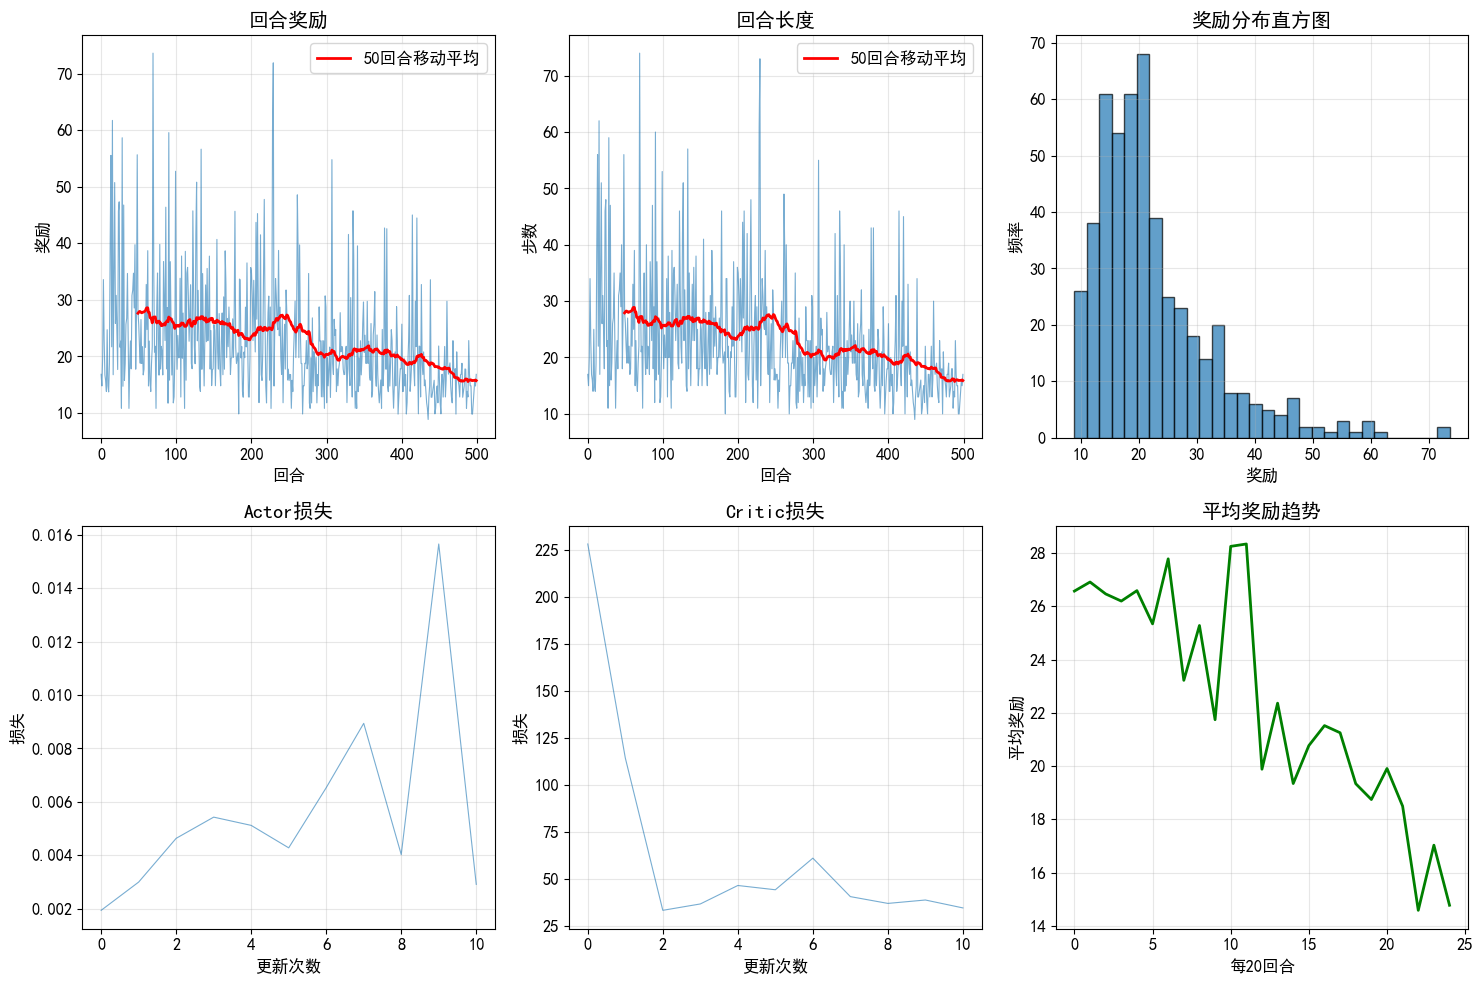


训练结果统计:
总回合数: 500
平均奖励: 22.43 ± 10.22
平均步数: 22.7 ± 10.3
最大奖励: 73.61
最小奖励: 8.87
最近100回合平均奖励: 16.95
模型尚未收敛: 考虑增加训练回合数或调整超参数

5. 测试PPO智能体

开始测试PPO智能体 (5回合)

=== 测试回合 1 ===
Step: 10
位置: -0.122, 角度: 7.0°
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
                            O                               
                            |                               
                            |                               
                            |                               
                           [|]                              
                                                            
------------------------------------------------------------
       

In [3]:
"""
强化学习PPO算法实现：平衡杆游戏

游戏说明：
- 一个杆子连接在一个小车上，可以左右移动
- 智能体控制小车施加的力，使杆子保持竖直
- 状态：小车位置、速度、杆子角度、角速度
- 动作：连续值，表示施加的力（-1到1）
- 奖励：杆子越接近竖直，奖励越高

PPO算法特点：
1. 使用重要性采样，限制策略更新幅度
2. 裁剪目标函数，防止过度更新
3. 使用优势函数估计，减少方差
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal, Categorical
import gym
from gym import spaces
import time
from collections import deque
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.size'] = 12                # 设置字体大小
# ============================================================================
# 第一部分：自定义平衡杆游戏环境
# ============================================================================

class BalancePoleEnv:
    """
    自定义平衡杆环境
    物理模拟简化版：小车上的倒立摆
    """

    def __init__(self):
        """
        初始化平衡杆环境

        状态空间（连续）：
        - 小车位置 x: [-2.4, 2.4]
        - 小车速度 v: [-inf, inf]
        - 杆子角度 θ: [-12°, 12°]（弧度制）
        - 杆子角速度 ω: [-inf, inf]

        动作空间（连续）：
        - 施加的力: [-1.0, 1.0]
        """
        # 物理参数
        self.gravity = 9.8  # 重力加速度
        self.mass_cart = 1.0  # 小车质量
        self.mass_pole = 0.1  # 杆子质量
        self.total_mass = self.mass_cart + self.mass_pole
        self.length = 0.5  # 杆子半长
        self.pole_mass_length = self.mass_pole * self.length
        self.force_mag = 10.0  # 力的缩放因子
        self.tau = 0.02  # 时间步长（秒）

        # 阈值
        self.x_threshold = 2.4  # 小车位置阈值
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # 杆子角度阈值（12度）

        # 状态空间：连续4维
        self.state_dim = 4

        # 动作空间：连续1维，范围[-1, 1]
        self.action_dim = 1
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # 奖励参数
        self.theta_penalty = 1.0  # 角度惩罚系数
        self.x_penalty = 0.1  # 位置惩罚系数

        # 状态
        self.state = None

        # 最大步数
        self.max_steps = 200
        self.current_step = 0

        print("平衡杆环境初始化完成")
        print(f"状态维度: {self.state_dim} (位置, 速度, 角度, 角速度)")
        print(f"动作维度: {self.action_dim} (力: -1.0 到 1.0)")
        print(f"最大步数: {self.max_steps}")

    def reset(self):
        """
        重置环境到初始状态

        返回：
        state: 初始状态数组
        """
        # 初始状态：在原点附近随机初始化
        self.state = np.array([
            np.random.uniform(low=-0.05, high=0.05),  # 位置
            np.random.uniform(low=-0.05, high=0.05),  # 速度
            np.random.uniform(low=-0.05, high=0.05),  # 角度
            np.random.uniform(low=-0.05, high=0.05)   # 角速度
        ], dtype=np.float32)

        self.current_step = 0
        return self.state.copy()

    def step(self, action):
        """
        执行一个动作

        参数：
        action: 动作值（力，范围[-1, 1]）

        返回：
        next_state, reward, done, info
        """
        # 确保动作在合理范围内
        action = np.clip(action, -1.0, 1.0)[0]

        # 从当前状态中提取变量
        x, x_dot, theta, theta_dot = self.state

        # 计算物理更新
        force = self.force_mag * action
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        # 物理方程（简化版倒立摆动力学）
        temp = (force + self.pole_mass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0/3.0 - self.mass_pole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.pole_mass_length * thetaacc * costheta / self.total_mass

        # 欧拉积分更新状态
        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc

        # 更新状态
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)

        # 检查是否终止
        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.current_step >= self.max_steps
        )

        # 计算奖励
        # 基础奖励：杆子越竖直，位置越居中，奖励越高
        reward = 1.0  # 存活奖励

        # 角度惩罚：角度越大，惩罚越大
        theta_penalty = self.theta_penalty * theta**2
        reward -= theta_penalty

        # 位置惩罚：偏离中心越远，惩罚越大
        x_penalty = self.x_penalty * x**2
        reward -= x_penalty

        # 归一化奖励到合理范围
        reward = float(reward)

        self.current_step += 1

        info = {
            "step": self.current_step,
            "theta": float(theta),
            "x": float(x),
            "force": float(action)
        }

        return self.state.copy(), reward, done, info

    def render(self, mode='human'):
        """
        可视化当前环境状态

        参数：
        mode: 渲染模式
        """
        x, _, theta, _ = self.state

        # 简单的文本渲染
        print(f"Step: {self.current_step}")
        print(f"位置: {x:.3f}, 角度: {theta*180/np.pi:.1f}°")

        # 简单的ASCII艺术表示
        screen_width = 60
        screen_height = 20

        cart_pos = int(screen_width // 2 + x * screen_width // self.x_threshold // 2)
        cart_pos = max(1, min(screen_width - 2, cart_pos))

        pole_length = screen_height // 4
        pole_end_x = int(cart_pos + pole_length * np.sin(theta))
        pole_end_y = screen_height // 2 - int(pole_length * np.cos(theta))

        # 创建画布
        canvas = [[' ' for _ in range(screen_width)] for _ in range(screen_height)]

        # 绘制小车
        cart_y = screen_height // 2
        canvas[cart_y][cart_pos-1:cart_pos+2] = ['[', '=', ']']

        # 绘制杆子
        if 0 <= pole_end_x < screen_width and 0 <= pole_end_y < screen_height:
            # 绘制杆子线
            dx = pole_end_x - cart_pos
            dy = pole_end_y - cart_y
            steps = max(abs(dx), abs(dy))

            if steps > 0:
                for i in range(steps + 1):
                    x_pos = cart_pos + int(dx * i / steps)
                    y_pos = cart_y + int(dy * i / steps)
                    if 0 <= x_pos < screen_width and 0 <= y_pos < screen_height:
                        canvas[y_pos][x_pos] = '|'

            # 绘制杆子末端
            canvas[pole_end_y][pole_end_x] = 'O'

        # 绘制地面
        ground_y = screen_height // 2 + 2
        canvas[ground_y] = ['-'] * screen_width

        # 打印画布
        for row in canvas:
            print(''.join(row))

        print("-" * screen_width)

        if mode == 'rgb_array':
            # 返回RGB数组用于matplotlib
            return np.zeros((screen_height, screen_width, 3), dtype=np.uint8)

    def close(self):
        """关闭环境"""
        pass


# ============================================================================
# 第二部分：PPO算法实现
# ============================================================================

class ActorNetwork(nn.Module):
    """
    Actor网络：策略网络
    输出动作的概率分布（连续动作：均值和标准差）
    """
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(ActorNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim * 2)  # 输出均值和标准差
        )

        # 初始化参数
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight, gain=0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, state):
        """前向传播"""
        output = self.net(state)

        # 将输出拆分为均值和标准差
        mean, log_std = output.chunk(2, dim=-1)

        # 限制标准差的范围（确保数值稳定）
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = torch.exp(log_std)

        return mean, std

    def get_action(self, state, deterministic=False):
        """
        根据状态选择动作

        参数：
        state: 状态
        deterministic: 是否确定性地选择动作（测试时使用）

        返回：
        action: 选择的动作
        log_prob: 动作的对数概率
        """
        mean, std = self.forward(state)

        if deterministic:
            # 测试时：直接使用均值作为动作
            action = mean
            log_prob = None
        else:
            # 训练时：从正态分布中采样
            dist = Normal(mean, std)
            action = dist.rsample()  # 使用重参数化技巧
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)

            # 限制动作范围[-1, 1]
            action = torch.tanh(action)

            # 修正对数概率（由于tanh变换）
            log_prob -= torch.log(1 - action.pow(2) + 1e-6).sum(dim=-1, keepdim=True)

        return action, log_prob


class CriticNetwork(nn.Module):
    """
    Critic网络：价值网络
    估计状态的价值（V值）
    """
    def __init__(self, state_dim, hidden_dim=64):
        super(CriticNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)  # 输出状态价值
        )

        # 初始化参数
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight, gain=1.0)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, state):
        """前向传播"""
        return self.net(state)


class PPOAgent:
    """
    PPO (Proximal Policy Optimization) 智能体

    PPO关键特点：
    1. 裁剪目标函数：限制策略更新幅度，防止过度更新
    2. 重要性采样：使用旧策略收集的数据更新新策略
    3. 广义优势估计 (GAE)：减少价值估计的方差

    算法流程：
    1. 使用当前策略收集数据
    2. 计算优势函数和回报
    3. 多次更新策略和价值网络（使用裁剪的PPO目标）
    """

    def __init__(self, state_dim, action_dim, device='cpu'):
        """
        初始化PPO智能体

        参数：
        state_dim: 状态维度
        action_dim: 动作维度
        device: 计算设备（'cpu' 或 'cuda'）
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.device = device

        # PPO超参数
        self.lr = 3e-4  # 学习率
        self.gamma = 0.99  # 折扣因子
        self.gae_lambda = 0.95  # GAE参数
        self.ppo_epochs = 10  # PPO更新轮数
        self.ppo_clip = 0.2  # 裁剪系数
        self.value_coef = 0.5  # 价值损失系数
        self.entropy_coef = 0.01  # 熵正则化系数
        self.batch_size = 64  # 批大小

        # 网络
        self.actor = ActorNetwork(state_dim, action_dim).to(device)
        self.critic = CriticNetwork(state_dim).to(device)

        # 优化器
        self.optimizer = optim.Adam([
            {'params': self.actor.parameters()},
            {'params': self.critic.parameters()}
        ], lr=self.lr)

        # 旧策略（用于重要性采样）
        self.old_actor = ActorNetwork(state_dim, action_dim).to(device)
        self.old_actor.load_state_dict(self.actor.state_dict())

        # 经验缓冲区
        self.memory = []

        print(f"PPO智能体初始化完成 (设备: {device})")
        print(f"学习率: {self.lr}, 折扣因子: {self.gamma}, GAE λ: {self.gae_lambda}")
        print(f"PPO轮数: {self.ppo_epochs}, 裁剪系数: {self.ppo_clip}")
        print(f"价值系数: {self.value_coef}, 熵系数: {self.entropy_coef}")

    def select_action(self, state, deterministic=False):
        """
        根据状态选择动作

        参数：
        state: 状态
        deterministic: 是否确定性选择动作

        返回：
        action: 选择的动作
        log_prob: 动作的对数概率
        value: 状态价值估计
        """
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            if deterministic:
                # 测试时：使用旧策略的均值
                mean, _ = self.old_actor(state_tensor)
                action = torch.tanh(mean)
                log_prob = None
            else:
                # 训练时：从旧策略中采样
                action, log_prob = self.old_actor.get_action(state_tensor)

            # 价值估计
            value = self.critic(state_tensor)

        return action.cpu().numpy()[0], log_prob.cpu().numpy()[0] if log_prob is not None else None, value.cpu().numpy()[0]

    def store_transition(self, transition):
        """存储经验转换"""
        self.memory.append(transition)

    def clear_memory(self):
        """清空经验缓冲区"""
        self.memory = []

    def compute_gae(self, rewards, values, dones, next_value):
        """
        计算广义优势估计 (GAE)

        GAE公式:
        A_t = δ_t + (γλ)δ_{t+1} + ... + (γλ)^{T-t+1}δ_{T-1}
        δ_t = r_t + γV(s_{t+1}) - V(s_t)

        参数：
        rewards: 奖励序列
        values: 价值估计序列
        dones: 终止标志序列
        next_value: 最后一个状态的价值

        返回：
        advantages: 优势函数序列
        returns: 回报序列
        """
        advantages = []
        returns = []

        gae = 0
        next_value = next_value

        # 反向计算
        for t in reversed(range(len(rewards))):
            # 如果是终止状态，下一个价值为0
            if dones[t]:
                next_value = 0

            # TD误差
            delta = rewards[t] + self.gamma * next_value - values[t]

            # GAE
            gae = delta + self.gamma * self.gae_lambda * gae

            # 优势函数
            advantages.insert(0, gae)

            # 回报
            returns.insert(0, gae + values[t])

            next_value = values[t]

        advantages = np.array(advantages)
        returns = np.array(returns)

        # 标准化优势函数（减少方差）
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        return advantages, returns

    def learn(self):
        """
        PPO学习更新

        更新步骤：
        1. 从经验中提取数据
        2. 计算优势函数和回报
        3. 多次更新网络（使用裁剪的PPO目标）
        """
        if len(self.memory) == 0:
            return

        # 从记忆中提取数据
        states = np.array([transition[0] for transition in self.memory])
        actions = np.array([transition[1] for transition in self.memory])
        log_probs = np.array([transition[2] for transition in self.memory])
        rewards = np.array([transition[3] for transition in self.memory])
        next_states = np.array([transition[4] for transition in self.memory])
        dones = np.array([transition[5] for transition in self.memory])
        values = np.array([transition[6] for transition in self.memory])

        # 计算最后一个状态的价值
        with torch.no_grad():
            next_state_tensor = torch.FloatTensor(next_states[-1]).unsqueeze(0).to(self.device)
            next_value = self.critic(next_state_tensor).cpu().numpy()[0]

        # 计算GAE和回报
        advantages, returns = self.compute_gae(rewards, values, dones, next_value)

        # 转换为张量
        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.FloatTensor(actions).to(self.device)
        old_log_probs_tensor = torch.FloatTensor(log_probs).to(self.device)
        returns_tensor = torch.FloatTensor(returns).unsqueeze(1).to(self.device)
        advantages_tensor = torch.FloatTensor(advantages).unsqueeze(1).to(self.device)

        # 多轮PPO更新
        total_actor_loss = 0
        total_critic_loss = 0
        total_loss = 0

        for _ in range(self.ppo_epochs):
            # 随机打乱数据
            indices = np.arange(len(states))
            np.random.shuffle(indices)

            # 小批量训练
            for start in range(0, len(states), self.batch_size):
                end = start + self.batch_size
                batch_indices = indices[start:end]

                # 获取批次数据
                batch_states = states_tensor[batch_indices]
                batch_actions = actions_tensor[batch_indices]
                batch_old_log_probs = old_log_probs_tensor[batch_indices]
                batch_returns = returns_tensor[batch_indices]
                batch_advantages = advantages_tensor[batch_indices]

                # 计算新策略的对数概率
                mean, std = self.actor(batch_states)
                dist = Normal(mean, std)
                new_log_probs = dist.log_prob(batch_actions).sum(dim=-1, keepdim=True)

                # 修正对数概率（由于tanh变换）
                new_log_probs -= torch.log(1 - torch.tanh(batch_actions).pow(2) + 1e-6).sum(dim=-1, keepdim=True)

                # 重要性采样比率
                ratio = torch.exp(new_log_probs - batch_old_log_probs)

                # 裁剪的PPO目标
                surr1 = ratio * batch_advantages
                surr2 = torch.clamp(ratio, 1 - self.ppo_clip, 1 + self.ppo_clip) * batch_advantages
                actor_loss = -torch.min(surr1, surr2).mean()

                # 熵正则化（鼓励探索）
                entropy = dist.entropy().mean()

                # 价值损失
                values_pred = self.critic(batch_states)
                critic_loss = nn.MSELoss()(values_pred, batch_returns)

                # 总损失
                loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy

                # 反向传播
                self.optimizer.zero_grad()
                loss.backward()

                # 梯度裁剪（防止梯度爆炸）
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)

                self.optimizer.step()

                # 记录损失
                total_actor_loss += actor_loss.item()
                total_critic_loss += critic_loss.item()
                total_loss += loss.item()

        # 更新旧策略
        self.old_actor.load_state_dict(self.actor.state_dict())

        # 清空记忆
        self.clear_memory()

        # 计算平均损失
        num_updates = self.ppo_epochs * (len(states) // self.batch_size + 1)
        avg_actor_loss = total_actor_loss / num_updates
        avg_critic_loss = total_critic_loss / num_updates
        avg_loss = total_loss / num_updates

        return avg_actor_loss, avg_critic_loss, avg_loss


# ============================================================================
# 第三部分：训练函数
# ============================================================================

def train_ppo(env, agent, episodes=1000, max_steps=200, update_freq=2048,
              log_freq=10, render_freq=50):
    """
    训练PPO智能体

    参数：
    env: 环境对象
    agent: PPO智能体对象
    episodes: 训练回合数
    max_steps: 每个回合最大步数
    update_freq: 每收集多少步经验更新一次
    log_freq: 每隔多少回合记录一次
    render_freq: 每隔多少回合渲染一次

    返回：
    training_history: 训练历史
    """
    print(f"\n开始PPO训练")
    print(f"总回合数: {episodes}, 最大步数/回合: {max_steps}")
    print(f"更新频率: 每 {update_freq} 步更新一次")

    training_history = {
        'episode_rewards': [],
        'episode_lengths': [],
        'actor_losses': [],
        'critic_losses': [],
        'avg_rewards': [],
        'avg_lengths': []
    }

    total_steps = 0
    episode_rewards = []
    episode_lengths = []

    for episode in range(episodes):
        state = env.reset()
        episode_reward = 0
        episode_length = 0

        for step in range(max_steps):
            # 选择动作
            action, log_prob, value = agent.select_action(state)

            # 执行动作
            next_state, reward, done, info = env.step(action)

            # 存储经验
            agent.store_transition((state, action, log_prob, reward, next_state, done, value))

            # 更新状态
            state = next_state
            episode_reward += reward
            episode_length += 1
            total_steps += 1

            # 定期更新策略
            if total_steps % update_freq == 0 and len(agent.memory) > 0:
                actor_loss, critic_loss, total_loss = agent.learn()
                training_history['actor_losses'].append(actor_loss)
                training_history['critic_losses'].append(critic_loss)

            # 渲染（定期）
            if episode % render_freq == 0 and step == 0:
                print(f"\n回合 {episode} 渲染:")
                env.render()

            if done:
                break

        # 记录本回合结果
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)

        # 记录到训练历史
        training_history['episode_rewards'].append(episode_reward)
        training_history['episode_lengths'].append(episode_length)

        # 定期打印训练进度
        if (episode + 1) % log_freq == 0:
            avg_reward = np.mean(episode_rewards[-log_freq:])
            avg_length = np.mean(episode_lengths[-log_freq:])

            training_history['avg_rewards'].append(avg_reward)
            training_history['avg_lengths'].append(avg_length)

            print(f"回合 {episode+1}/{episodes} - "
                  f"平均奖励: {avg_reward:.2f}, "
                  f"平均步数: {avg_length:.1f}, "
                  f"总步数: {total_steps}")

    print("\n训练完成!")
    return training_history


# ============================================================================
# 第四部分：可视化函数
# ============================================================================

def plot_training_results(training_history, window_size=50):
    """
    绘制PPO训练结果

    参数：
    training_history: 训练历史字典
    window_size: 移动平均窗口大小
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. 回合奖励
    rewards = training_history['episode_rewards']
    axes[0, 0].plot(rewards, alpha=0.6, linewidth=0.8)
    axes[0, 0].set_title('回合奖励')
    axes[0, 0].set_xlabel('回合')
    axes[0, 0].set_ylabel('奖励')
    axes[0, 0].grid(True, alpha=0.3)

    # 移动平均
    if len(rewards) >= window_size:
        moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        axes[0, 0].plot(range(window_size-1, len(rewards)), moving_avg,
                       'r-', linewidth=2, label=f'{window_size}回合移动平均')
        axes[0, 0].legend()

    # 2. 回合长度
    lengths = training_history['episode_lengths']
    axes[0, 1].plot(lengths, alpha=0.6, linewidth=0.8)
    axes[0, 1].set_title('回合长度')
    axes[0, 1].set_xlabel('回合')
    axes[0, 1].set_ylabel('步数')
    axes[0, 1].grid(True, alpha=0.3)

    if len(lengths) >= window_size:
        moving_avg = np.convolve(lengths, np.ones(window_size)/window_size, mode='valid')
        axes[0, 1].plot(range(window_size-1, len(lengths)), moving_avg,
                       'r-', linewidth=2, label=f'{window_size}回合移动平均')
        axes[0, 1].legend()

    # 3. 奖励分布直方图
    axes[0, 2].hist(rewards, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].set_title('奖励分布直方图')
    axes[0, 2].set_xlabel('奖励')
    axes[0, 2].set_ylabel('频率')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Actor损失
    if training_history['actor_losses']:
        actor_losses = training_history['actor_losses']
        axes[1, 0].plot(actor_losses, alpha=0.6, linewidth=0.8)
        axes[1, 0].set_title('Actor损失')
        axes[1, 0].set_xlabel('更新次数')
        axes[1, 0].set_ylabel('损失')
        axes[1, 0].grid(True, alpha=0.3)

    # 5. Critic损失
    if training_history['critic_losses']:
        critic_losses = training_history['critic_losses']
        axes[1, 1].plot(critic_losses, alpha=0.6, linewidth=0.8)
        axes[1, 1].set_title('Critic损失')
        axes[1, 1].set_xlabel('更新次数')
        axes[1, 1].set_ylabel('损失')
        axes[1, 1].grid(True, alpha=0.3)

    # 6. 平均奖励趋势
    if training_history['avg_rewards']:
        avg_rewards = training_history['avg_rewards']
        axes[1, 2].plot(avg_rewards, 'g-', linewidth=2)
        axes[1, 2].set_title('平均奖励趋势')
        axes[1, 2].set_xlabel(f'每{len(rewards)//len(avg_rewards)}回合')
        axes[1, 2].set_ylabel('平均奖励')
        axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print("\n训练结果统计:")
    print(f"总回合数: {len(rewards)}")
    print(f"平均奖励: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    print(f"平均步数: {np.mean(lengths):.1f} ± {np.std(lengths):.1f}")
    print(f"最大奖励: {np.max(rewards):.2f}")
    print(f"最小奖励: {np.min(rewards):.2f}")

    # 检查收敛性
    if len(rewards) >= 100:
        recent_avg = np.mean(rewards[-100:])
        print(f"最近100回合平均奖励: {recent_avg:.2f}")
        if recent_avg > 150:  # 平衡杆通常认为>195为成功
            print("模型已收敛: 智能体学会了平衡杆子")
        elif recent_avg > 100:
            print("模型部分收敛: 智能体能保持一定时间平衡")
        else:
            print("模型尚未收敛: 考虑增加训练回合数或调整超参数")


# ============================================================================
# 第五部分：测试函数
# ============================================================================

def test_ppo_agent(env, agent, test_episodes=10, render=True):
    """
    测试训练好的PPO智能体

    参数：
    env: 环境对象
    agent: PPO智能体对象
    test_episodes: 测试回合数
    render: 是否渲染

    返回：
    test_results: 测试结果
    """
    print(f"\n开始测试PPO智能体 ({test_episodes}回合)")

    test_rewards = []
    test_lengths = []

    for episode in range(test_episodes):
        state = env.reset()
        episode_reward = 0
        episode_length = 0
        done = False

        if render:
            print(f"\n=== 测试回合 {episode+1} ===")

        while not done:
            # 使用确定性策略选择动作（测试时不探索）
            action, _, _ = agent.select_action(state, deterministic=True)

            # 执行动作
            next_state, reward, done, info = env.step(action)

            # 更新状态
            state = next_state
            episode_reward += reward
            episode_length += 1

            if render and episode_length % 10 == 0:
                env.render()
                print(f"步数: {episode_length}, 奖励: {reward:.2f}, 角度: {info['theta']*180/np.pi:.1f}°")
                time.sleep(0.05)

            if episode_length >= 200:  # 最大步数
                break

        test_rewards.append(episode_reward)
        test_lengths.append(episode_length)

        if render:
            print(f"测试回合 {episode+1} 完成: 总奖励={episode_reward:.2f}, 步数={episode_length}")

    # 打印测试结果
    print("\n测试结果统计:")
    print(f"平均奖励: {np.mean(test_rewards):.2f} ± {np.std(test_rewards):.2f}")
    print(f"平均步数: {np.mean(test_lengths):.1f} ± {np.std(test_lengths):.1f}")
    print(f"成功率: {sum(1 for r in test_lengths if r >= 195) / test_episodes * 100:.1f}%")

    return {
        'rewards': test_rewards,
        'lengths': test_lengths,
        'avg_reward': np.mean(test_rewards),
        'avg_length': np.mean(test_lengths)
    }


# ============================================================================
# 第六部分：主函数
# ============================================================================

def main_ppo():
    """
    PPO算法主函数
    """
    print("=" * 60)
    print("PPO算法实现：平衡杆游戏")
    print("=" * 60)

    # 设置随机种子（确保可重复性）
    np.random.seed(42)
    torch.manual_seed(42)

    # 1. 创建环境
    print("\n1. 创建平衡杆环境")
    env = BalancePoleEnv()

    # 2. 创建PPO智能体
    print("\n2. 创建PPO智能体")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    agent = PPOAgent(
        state_dim=env.state_dim,
        action_dim=env.action_dim,
        device=device
    )

    # 3. 训练PPO智能体
    print("\n3. 开始PPO训练")
    # 注意：完整训练需要较多时间，这里使用较少的回合数进行演示
    training_history = train_ppo(
        env,
        agent,
        episodes=500,  # 训练回合数（实际应用可能需要1000+）
        max_steps=200,
        update_freq=1024,  # 更新频率
        log_freq=20,  # 记录频率
        render_freq=100  # 渲染频率
    )

    # 4. 可视化训练结果
    print("\n4. 可视化训练结果")
    plot_training_results(training_history)

    # 5. 测试智能体
    print("\n5. 测试PPO智能体")
    test_results = test_ppo_agent(env, agent, test_episodes=5, render=True)

    # 6. 保存模型
    print("\n6. 保存训练好的模型")
    torch.save({
        'actor_state_dict': agent.actor.state_dict(),
        'critic_state_dict': agent.critic.state_dict(),
        'training_history': training_history,
        'test_results': test_results
    }, 'ppo_balance_pole.pth')
    print("模型已保存为 'ppo_balance_pole.pth'")

    print("\n" + "=" * 60)
    print("PPO算法演示完成！")
    print("=" * 60)

    env.close()


def compare_algorithms():
    """
    比较不同强化学习算法的适用性
    """
    print("=" * 60)
    print("强化学习算法适用性比较")
    print("=" * 60)

    algorithms = [
        {
            "name": "Q-learning",
            "type": "值函数方法",
            "动作空间": "离散",
            "状态空间": "离散或低维连续",
            "样本效率": "低",
            "收敛速度": "快",
            "稳定性": "中等",
            "适用场景": "简单游戏、网格世界",
            "已实现": "✓"
        },
        {
            "name": "PPO",
            "type": "策略梯度方法",
            "动作空间": "连续/离散",
            "状态空间": "连续",
            "样本效率": "高",
            "收敛速度": "中等",
            "稳定性": "高",
            "适用场景": "机器人控制、复杂游戏",
            "已实现": "✓"
        },
        {
            "name": "DQN",
            "type": "值函数方法",
            "动作空间": "离散",
            "状态空间": "高维连续（如图像）",
            "样本效率": "中等",
            "收敛速度": "慢",
            "稳定性": "中等",
            "适用场景": "Atari游戏、视觉输入任务",
            "已实现": "✗"
        },
        {
            "name": "SAC",
            "type": "策略梯度方法",
            "动作空间": "连续",
            "状态空间": "连续",
            "样本效率": "高",
            "收敛速度": "慢",
            "稳定性": "高",
            "适用场景": "需要高度探索的任务",
            "已实现": "✗"
        }
    ]

    # 打印比较表格
    print("\n算法比较表格:")
    print("-" * 90)
    print(f"{'算法':<10} {'类型':<15} {'动作空间':<10} {'状态空间':<15} {'样本效率':<10} {'稳定性':<10} {'已实现':<8}")
    print("-" * 90)

    for algo in algorithms:
        print(f"{algo['name']:<10} {algo['type']:<15} {algo['动作空间']:<10} "
              f"{algo['状态空间']:<15} {algo['样本效率']:<10} {algo['稳定性']:<10} {algo['已实现']:<8}")

    print("-" * 90)

    # 选择建议
    print("\n算法选择建议:")
    print("1. 对于简单离散任务（如网格世界） → Q-learning")
    print("2. 对于连续控制任务（如机器人、平衡杆） → PPO")
    print("3. 对于图像输入的游戏 → DQN")
    print("4. 对于需要高度探索的连续任务 → SAC")

    print("\n本项目中已实现:")
    print("- Q-learning: 用于离散网格世界")
    print("- PPO: 用于连续控制平衡杆")

    return algorithms


# ============================================================================
# 第七部分：示例使用
# ============================================================================

if __name__ == "__main__":
    # 主程序
    print("强化学习算法演示程序")
    print("1. 比较不同算法")
    print("2. 运行PPO算法演示")

    choice = input("请选择 (1 或 2): ").strip()

    if choice == "1":
        compare_algorithms()
    elif choice == "2":
        # 运行PPO演示
        main_ppo()
    else:
        print("无效选择，运行PPO演示...")
        main_ppo()